In [4]:
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
from dataset import ISBIVesselDataset3D, make_isbi_dataloaders
import matplotlib.pyplot as plt
import os
import torch.multiprocessing as mp
from torch.utils.data import DistributedSampler, DataLoader
from MiniDiLoCo.train import Trainer, diloco_worker
from MiniDiLoCo.strategy import Diloco
from MiniDiLoCo.utils import setup, cleanup
from UNet3D import UNet3D
import torch
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.ndimage import distance_transform_edt
import PIL.Image as PILImage
import base64, io
from skimage.morphology import skeletonize
from MiniDiLoCo.clmr import CLMR
from lion_pytorch import Lion
import json
import time

/home/saxel/DopplerHolographySegmentationTraining/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Config

In [5]:
WORLD_SIZE = 3
NUM_EPOCHS = 8
BATCH_SIZE = 1
LR = 1e-3
SAVE_PATH = str(Path("checkpoints/unet3d_diloco.pth"))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
train_dl, val_dl = make_isbi_dataloaders(
    dataset_root="dataset_isbi/",
    depth=16,
    img_size=(512, 320),
    train_ratio=0.8,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(f"train_dl size: {len(train_dl)}")
batch = next(iter(train_dl))
volume = batch["pixel_values"]
mask = batch["labels"]
print(f"Volume shape : {volume.shape}")
print(f"Mask shape   : {mask.shape}")

145 cas trouvés
Train: 116 cas -> 464 échantillons (x4)
Val:   29 cas -> 29 échantillons
train_dl size: 464
Volume shape : torch.Size([1, 1, 16, 512, 320])
Mask shape   : torch.Size([1, 1, 16, 512, 320])


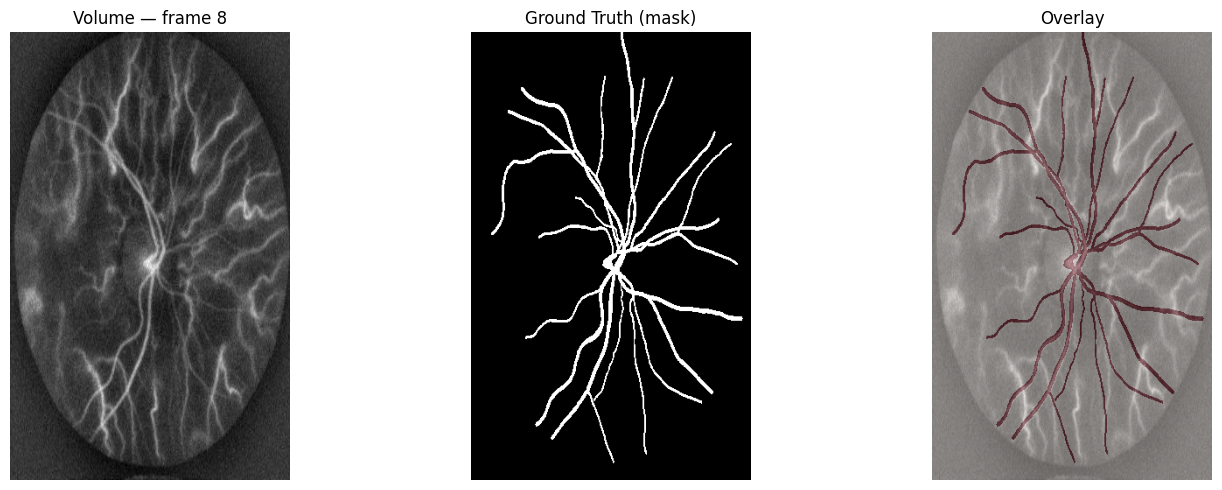

In [7]:
batch = next(iter(train_dl))  # (B, 1, D, H, W)

vol = batch["pixel_values"][0, 0].cpu().numpy()  # (D, H, W)
msk = batch["labels"][0, 0].cpu().numpy()        # (D, H, W)

# Affichage du sample
mid = vol.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(vol[mid], cmap='gray')
axes[0].set_title(f"Volume — frame {mid}")
axes[0].axis('off')

axes[1].imshow(msk[mid], cmap='gray')
axes[1].set_title("Ground Truth (mask)")
axes[1].axis('off')

axes[2].imshow(vol[mid], cmap='gray')
axes[2].imshow(msk[mid], cmap='Reds', alpha=0.4)
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [8]:
def verify_splits(dataset, all_splits, world_size):
    video_full, mask_full = dataset[0]["pixel_values"], dataset[0]["labels"]
    mid = video_full.shape[1] // 2

    fig, axes = plt.subplots(world_size + 1, 2, figsize=(10, 4 * (world_size + 1)))

    axes[0, 0].imshow(video_full[0, mid].numpy(), cmap='gray')
    axes[0, 0].set_title(f"[FULL] Video — frame {mid} | shape: {tuple(video_full.shape)}")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(mask_full[0, mid].numpy(), cmap='gray')
    axes[0, 1].set_title(f"[FULL] Mask — shape: {tuple(mask_full.shape)}")
    axes[0, 1].axis('off')

    for rank in range(world_size):
        v_chunk, m_chunk = all_splits[0][rank]["pixel_values"], all_splits[0][rank]["labels"]
        axes[rank + 1, 0].imshow(v_chunk[0, mid].numpy(), cmap='gray')
        axes[rank + 1, 0].set_title(f"[GPU {rank}] Video chunk | shape: {tuple(v_chunk.shape)}")
        axes[rank + 1, 0].axis('off')

        axes[rank + 1, 1].imshow(m_chunk[0, mid].numpy(), cmap='gray')
        axes[rank + 1, 1].set_title(f"[GPU {rank}] Mask chunk | shape: {tuple(m_chunk.shape)}")
        axes[rank + 1, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Optimizers benchmark

In [6]:
# ─── Outer optimizers ────────────────────────────────────────────────────────
_SGD_outer = {
    "outer_cls": torch.optim.SGD,
    "outer_kwargs": {"lr": 0.7, "nesterov": True, "momentum": 0.9},
}

_AdamW_outer = {
    "outer_cls": torch.optim.AdamW,
    "outer_kwargs": {"lr": 0.7, "weight_decay": 1e-2},
}

_Adam_outer = {
    "outer_cls": torch.optim.Adam,
    "outer_kwargs": {"lr": 0.7, "betas": (0.9, 0.999)},
}
_SGDPlain_outer = {
    "outer_cls": torch.optim.SGD,
    "outer_kwargs": {"lr": 0.7, "momentum": 0.9, "nesterov": False},
}
_RMSprop_outer = {
    "outer_cls": torch.optim.RMSprop,
    "outer_kwargs": {"lr": 0.7, "alpha": 0.99, "momentum": 0.9},
}
_Lion_outer = {
    "outer_cls": Lion,
    "outer_kwargs": {"lr": 0.07, "weight_decay": 1e-2, "betas": (0.9, 0.99)},
}
_CLMR_outer = {
    "outer_cls": CLMR,
    "outer_kwargs": {
        "base_lr": 1e-4, "max_lr": 0.05,
        "base_momentum": 0.85, "max_momentum": 0.95,
        "cycle_size": 20,
    },
}

OPTIMIZER_CONFIGS = {

    # ── Adam inner ──────────────────────────────────────────────────────────
    "Adam_inner__SGD_outer":      {"inner_cls": torch.optim.Adam, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-4}, **_SGD_outer},
    "Adam_inner__AdamW_outer":    {"inner_cls": torch.optim.Adam, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-4}, **_AdamW_outer},
    "Adam_inner__Adam_outer":     {"inner_cls": torch.optim.Adam, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-4}, **_Adam_outer},
    "Adam_inner__SGDPlain_outer": {"inner_cls": torch.optim.Adam, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-4}, **_SGDPlain_outer},
    "Adam_inner__RMSprop_outer":  {"inner_cls": torch.optim.Adam, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-4}, **_RMSprop_outer},
    "Adam_inner__Lion_outer":     {"inner_cls": torch.optim.Adam, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-4}, **_Lion_outer},
    "Adam_inner__CLMR_outer":     {"inner_cls": torch.optim.Adam, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-4}, **_CLMR_outer},

    # ── AdamW inner ─────────────────────────────────────────────────────────
    "AdamW_inner__SGD_outer":      {"inner_cls": torch.optim.AdamW, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-2}, **_SGD_outer},
    "AdamW_inner__AdamW_outer":    {"inner_cls": torch.optim.AdamW, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-2}, **_AdamW_outer},
    "AdamW_inner__Adam_outer":     {"inner_cls": torch.optim.AdamW, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-2}, **_Adam_outer},
    "AdamW_inner__SGDPlain_outer": {"inner_cls": torch.optim.AdamW, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-2}, **_SGDPlain_outer},
    "AdamW_inner__RMSprop_outer":  {"inner_cls": torch.optim.AdamW, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-2}, **_RMSprop_outer},
    "AdamW_inner__Lion_outer":     {"inner_cls": torch.optim.AdamW, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-2}, **_Lion_outer},
    "AdamW_inner__CLMR_outer":     {"inner_cls": torch.optim.AdamW, "inner_kwargs": {"lr": 1e-3, "betas": (0.9, 0.999), "weight_decay": 1e-2}, **_CLMR_outer},

    # ── SGD inner ────────────────────────────────────────────────────────────
    "SGD_inner__SGD_outer":      {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": False}, **_SGD_outer},
    "SGD_inner__AdamW_outer":    {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": False}, **_AdamW_outer},
    "SGD_inner__Adam_outer":     {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": False}, **_Adam_outer},
    "SGD_inner__SGDPlain_outer": {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": False}, **_SGDPlain_outer},
    "SGD_inner__RMSprop_outer":  {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": False}, **_RMSprop_outer},
    "SGD_inner__Lion_outer":     {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": False}, **_Lion_outer},
    "SGD_inner__CLMR_outer":     {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": False}, **_CLMR_outer},

    # ── SGD Nesterov inner ───────────────────────────────────────────────────
    "SGDNesterov_inner__SGD_outer":      {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": True}, **_SGD_outer},
    "SGDNesterov_inner__AdamW_outer":    {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": True}, **_AdamW_outer},
    "SGDNesterov_inner__Adam_outer":     {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": True}, **_Adam_outer},
    "SGDNesterov_inner__SGDPlain_outer": {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": True}, **_SGDPlain_outer},
    "SGDNesterov_inner__RMSprop_outer":  {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": True}, **_RMSprop_outer},
    "SGDNesterov_inner__Lion_outer":     {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": True}, **_Lion_outer},
    "SGDNesterov_inner__CLMR_outer":     {"inner_cls": torch.optim.SGD, "inner_kwargs": {"lr": 0.01, "momentum": 0.9, "nesterov": True}, **_CLMR_outer},

    # ── RMSprop inner ────────────────────────────────────────────────────────
    "RMSprop_inner__SGD_outer":      {"inner_cls": torch.optim.RMSprop, "inner_kwargs": {"lr": 1e-3, "alpha": 0.99, "momentum": 0.9, "weight_decay": 1e-4}, **_SGD_outer},
    "RMSprop_inner__AdamW_outer":    {"inner_cls": torch.optim.RMSprop, "inner_kwargs": {"lr": 1e-3, "alpha": 0.99, "momentum": 0.9, "weight_decay": 1e-4}, **_AdamW_outer},
    "RMSprop_inner__Adam_outer":     {"inner_cls": torch.optim.RMSprop, "inner_kwargs": {"lr": 1e-3, "alpha": 0.99, "momentum": 0.9, "weight_decay": 1e-4}, **_Adam_outer},
    "RMSprop_inner__SGDPlain_outer": {"inner_cls": torch.optim.RMSprop, "inner_kwargs": {"lr": 1e-3, "alpha": 0.99, "momentum": 0.9, "weight_decay": 1e-4}, **_SGDPlain_outer},
    "RMSprop_inner__RMSprop_outer":  {"inner_cls": torch.optim.RMSprop, "inner_kwargs": {"lr": 1e-3, "alpha": 0.99, "momentum": 0.9, "weight_decay": 1e-4}, **_RMSprop_outer},
    "RMSprop_inner__Lion_outer":     {"inner_cls": torch.optim.RMSprop, "inner_kwargs": {"lr": 1e-3, "alpha": 0.99, "momentum": 0.9, "weight_decay": 1e-4}, **_Lion_outer},
    "RMSprop_inner__CLMR_outer":     {"inner_cls": torch.optim.RMSprop, "inner_kwargs": {"lr": 1e-3, "alpha": 0.99, "momentum": 0.9, "weight_decay": 1e-4}, **_CLMR_outer},

    # ── Lion inner ───────────────────────────────────────────────────────────
    "Lion_inner__SGD_outer":      {"inner_cls": Lion, "inner_kwargs": {"lr": 1e-4, "betas": (0.9, 0.99), "weight_decay": 1e-2}, **_SGD_outer},
    "Lion_inner__AdamW_outer":    {"inner_cls": Lion, "inner_kwargs": {"lr": 1e-4, "betas": (0.9, 0.99), "weight_decay": 1e-2}, **_AdamW_outer},
    "Lion_inner__Adam_outer":     {"inner_cls": Lion, "inner_kwargs": {"lr": 1e-4, "betas": (0.9, 0.99), "weight_decay": 1e-2}, **_Adam_outer},
    "Lion_inner__SGDPlain_outer": {"inner_cls": Lion, "inner_kwargs": {"lr": 1e-4, "betas": (0.9, 0.99), "weight_decay": 1e-2}, **_SGDPlain_outer},
    "Lion_inner__RMSprop_outer":  {"inner_cls": Lion, "inner_kwargs": {"lr": 1e-4, "betas": (0.9, 0.99), "weight_decay": 1e-2}, **_RMSprop_outer},
    "Lion_inner__Lion_outer":     {"inner_cls": Lion, "inner_kwargs": {"lr": 1e-4, "betas": (0.9, 0.99), "weight_decay": 1e-2}, **_Lion_outer},
    "Lion_inner__CLMR_outer":     {"inner_cls": Lion, "inner_kwargs": {"lr": 1e-4, "betas": (0.9, 0.99), "weight_decay": 1e-2}, **_CLMR_outer},

    # ── CLMR inner ───────────────────────────────────────────────────────────
    "CLMR_inner__SGD_outer":      {"inner_cls": CLMR, "inner_kwargs": {"base_lr": 5e-4, "max_lr": 0.05, "base_momentum": 0.85, "max_momentum": 0.95, "cycle_size": 20}, **_SGD_outer},
    "CLMR_inner__AdamW_outer":    {"inner_cls": CLMR, "inner_kwargs": {"base_lr": 5e-4, "max_lr": 0.05, "base_momentum": 0.85, "max_momentum": 0.95, "cycle_size": 20}, **_AdamW_outer},
    "CLMR_inner__Adam_outer":     {"inner_cls": CLMR, "inner_kwargs": {"base_lr": 5e-4, "max_lr": 0.05, "base_momentum": 0.85, "max_momentum": 0.95, "cycle_size": 20}, **_Adam_outer},
    "CLMR_inner__SGDPlain_outer": {"inner_cls": CLMR, "inner_kwargs": {"base_lr": 5e-4, "max_lr": 0.05, "base_momentum": 0.85, "max_momentum": 0.95, "cycle_size": 20}, **_SGDPlain_outer},
    "CLMR_inner__RMSprop_outer":  {"inner_cls": CLMR, "inner_kwargs": {"base_lr": 5e-4, "max_lr": 0.05, "base_momentum": 0.85, "max_momentum": 0.95, "cycle_size": 20}, **_RMSprop_outer},
    "CLMR_inner__Lion_outer":     {"inner_cls": CLMR, "inner_kwargs": {"base_lr": 5e-4, "max_lr": 0.05, "base_momentum": 0.85, "max_momentum": 0.95, "cycle_size": 20}, **_Lion_outer},
    "CLMR_inner__CLMR_outer":     {"inner_cls": CLMR, "inner_kwargs": {"base_lr": 5e-4, "max_lr": 0.05, "base_momentum": 0.85, "max_momentum": 0.95, "cycle_size": 20}, **_CLMR_outer},
}

print(f"{len(OPTIMIZER_CONFIGS)} combinaisons chargées.")

49 combinaisons chargées.


In [7]:
Path("benchmark_results").mkdir(exist_ok=True)
RESULTS_PATH = "benchmark_results/optimizer_benchmark.json"


def dice_score(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    target = target.float()
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return ((2 * inter + eps) / (union + eps)).item()


def sensitivity_score(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    target = target.float()
    tp = (pred * target).sum()
    fn = ((1 - pred) * target).sum()
    return ((tp + eps) / (tp + fn + eps)).item()


def cl_dice_score(pred, target, eps=1e-6):
    pred_np = (pred > 0.5).cpu().numpy().astype(np.uint8)
    target_np = target.cpu().numpy().astype(np.uint8)

    def cl_score(v, s):
        return (v * s).sum() / (s.sum() + eps)

    skel_pred = skeletonize(pred_np)
    skel_target = skeletonize(target_np)

    t_prec = cl_score(pred_np, skel_target)
    t_sens = cl_score(target_np, skel_pred)
    return (2 * t_prec * t_sens / (t_prec + t_sens + eps))


def hd95_score(pred, target):
    pred_np = (pred > 0.5).cpu().numpy().astype(bool)
    target_np = target.cpu().numpy().astype(bool)

    if pred_np.sum() == 0 or target_np.sum() == 0:
        return float("nan")

    dt_target = distance_transform_edt(~target_np)
    dt_pred = distance_transform_edt(~pred_np)

    d_pred_to_target = dt_target[pred_np]
    d_target_to_pred = dt_pred[target_np]

    all_d = np.concatenate([d_pred_to_target, d_target_to_pred])
    return float(np.percentile(all_d, 95))


@torch.no_grad()
def evaluate_model(model, val_dl, device):
    model.eval()
    dices, sens, cldices, hd95s = [], [], [], []

    for batch in val_dl:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        logits = model(pixel_values)
        preds = torch.sigmoid(logits)

        for b in range(preds.shape[0]):
            p, t = preds[b, 0], labels[b, 0]
            dices.append(dice_score(p, t))
            sens.append(sensitivity_score(p, t))
            cldices.append(cl_dice_score(p, t))
            hd95s.append(hd95_score(p, t))

    model.train()
    return {
        "dice": float(np.nanmean(dices)),
        "sensitivity": float(np.nanmean(sens)),
        "cl_dice": float(np.nanmean(cldices)),
        "hd95": float(np.nanmean(hd95s)),
    }


def run_one_config(name, config, dataset, val_dl, loss_fn, num_epochs,
                    batch_size, mode, world_size, device):
    print(f"\n{'='*60}\n▶ {name}\n{'='*60}")

    unet3d = UNet3D(1, 1)
    unet3d.share_memory()

    save_path = f"checkpoints/{name}.pth"

    try:
        mp.spawn(
            diloco_worker,
            args=(
                world_size, unet3d, dataset, batch_size, loss_fn,
                num_epochs, config["inner_kwargs"].get("lr", 1e-3), save_path,
                config["inner_cls"], config["inner_kwargs"],
                config["outer_cls"], config["outer_kwargs"],
                mode,
            ),
            nprocs=world_size,
            join=True,
        )

        loss_path = f"checkpoints/{name}_loss.json"
        with open(loss_path, "r") as f:
            loss_history = json.load(f)

        state_dict = torch.load(f"checkpoints/{name}.pth", map_location=device)
        unet3d.load_state_dict(state_dict)

        unet3d = unet3d.to(device)
        metrics = evaluate_model(unet3d, val_dl, device)

        return {
            "status": "ok",
            "loss_history": loss_history,
            "final_loss": loss_history[-1] if loss_history else None,
            "metrics": metrics,
        }

    except Exception as e:
        print(f"❌ Erreur sur {name}: {e}")
        return {"status": "error", "error": str(e)}

all_results = {}

if Path(RESULTS_PATH).exists():
    with open(RESULTS_PATH, "r") as f:
        all_results = json.load(f)

for name, config in OPTIMIZER_CONFIGS.items():
    if name in all_results and all_results[name].get("status") == "ok":
        print(f"⏭ {name} déjà fait, skip.")
        continue

    dataset = train_dl.dataset
    loss_fn = torch.nn.BCEWithLogitsLoss()
    MODE = "full"  # "chunked" ou "full"

    start = time.time()
    result = run_one_config(
        name, config, dataset, val_dl, loss_fn,
        num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, mode=MODE,
        world_size=3, device=DEVICE,
    )
    result[("durati"
            "on_sec")] = time.time() - start
    all_results[name] = result

    with open(RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)

    print(f"✅ {name} terminé en {result['duration_sec']:.1f}s")

print(f"\n🏁 Benchmark terminé — résultats dans {RESULTS_PATH}")


▶ Adam_inner__SGD_outer
Rank 2: DiLoCo H=50Rank 0: DiLoCo H=50

TAILLE DU DATALOADER: 155TAILLE DU DATALOADER: 155

Rank 1: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank: 1 - Outer step: 0 - Average loss: 0.5072400844097138
Rank: 0 - Outer step: 0 - Average loss: 0.5079720568656921
Rank: 2 - Outer step: 0 - Average loss: 0.5029540288448334
Rank: 0 - Outer step: 1 - Average loss: 0.3225883936882019
Rank: 1 - Outer step: 1 - Average loss: 0.32762073159217836
Rank: 2 - Outer step: 1 - Average loss: 0.3251853448152542
Rank: 0 - Outer step: 2 - Average loss: 0.2138612088561058
Rank: 1 - Outer step: 2 - Average loss: 0.2141912731528282
Rank: 2 - Outer step: 2 - Average loss: 0.2092167231440544
Rank: 0 - Outer step: 3 - Average loss: 0.15899455159902573
Rank: 2 - Outer step: 3 - Average loss: 0.1625138621032238
Rank: 1 - Outer step: 3 - Average loss: 0.16082988172769547
Rank: 0 - Outer step: 4 - Average loss: 0.14842853784561158
Rank: 1 - Outer step: 4 - Average loss: 0.14849651321768761
Rank: 

/home/saxel/DopplerHolographySegmentationTraining/.venv/lib/python3.12/site-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


✅ Adam_inner__SGD_outer terminé en 816.5s

▶ Adam_inner__AdamW_outer
Rank 1: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank 2: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank 0: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank: 0 - Outer step: 0 - Average loss: 0.43737175583839416
Rank: 1 - Outer step: 0 - Average loss: 0.4377901804447174
Rank: 2 - Outer step: 0 - Average loss: 0.4356916546821594
Rank: 1 - Outer step: 1 - Average loss: 0.8004330629110337Rank: 0 - Outer step: 1 - Average loss: 0.8246627140045166

Rank: 2 - Outer step: 1 - Average loss: 0.8557688623666764
Rank: 2 - Outer step: 2 - Average loss: 0.3979716089367866
Rank: 1 - Outer step: 2 - Average loss: 0.38702100157737734
Rank: 0 - Outer step: 2 - Average loss: 0.411890404522419
Rank: 0 - Outer step: 3 - Average loss: 0.45453949391841886
Rank: 1 - Outer step: 3 - Average loss: 0.4622428095340729
Rank: 2 - Outer step: 3 - Average loss: 0.4507887116074562
Rank: 1 - Outer step: 4 - Average loss: 0.2729701367020607
Rank: 0 - Outer step: 4 

/home/saxel/DopplerHolographySegmentationTraining/.venv/lib/python3.12/site-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)
/tmp/ipykernel_1456952/306497464.py:77: RuntimeWarning: Mean of empty slice
  "hd95": float(np.nanmean(hd95s)),


✅ Adam_inner__AdamW_outer terminé en 772.1s

▶ Adam_inner__Adam_outer
Rank 0: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank 1: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank 2: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank: 0 - Outer step: 0 - Average loss: 0.5769317299127579
Rank: 2 - Outer step: 0 - Average loss: 0.5754758965969086
Rank: 1 - Outer step: 0 - Average loss: 0.5794576227664947
Rank: 0 - Outer step: 1 - Average loss: 0.43036839604377747
Rank: 1 - Outer step: 1 - Average loss: 0.4063588935136795
Rank: 2 - Outer step: 1 - Average loss: 0.4501212736964226
Rank: 1 - Outer step: 2 - Average loss: 0.42634701877832415
Rank: 0 - Outer step: 2 - Average loss: 0.4491222661733627
Rank: 2 - Outer step: 2 - Average loss: 0.4384791818261147
Rank: 0 - Outer step: 3 - Average loss: 0.5442868399620057
Rank: 1 - Outer step: 3 - Average loss: 0.5931102958321571
Rank: 2 - Outer step: 3 - Average loss: 0.5404966008663178
Rank: 1 - Outer step: 4 - Average loss: 0.278282615840435
Rank: 0 - Outer step: 4 

...

✅ CLMR_inner__RMSprop_outer terminé en 1140.1s

▶ CLMR_inner__Lion_outer
Rank 2: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank 0: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank 1: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank: 1 - Outer step: 0 - Average loss: 0.2395109124481678
Rank: 2 - Outer step: 0 - Average loss: 0.23396526023745537
Rank: 0 - Outer step: 0 - Average loss: 0.24272885262966157
Rank: 1 - Outer step: 1 - Average loss: 0.23587412387132645
Rank: 0 - Outer step: 1 - Average loss: 0.2412775883078575
Rank: 2 - Outer step: 1 - Average loss: 0.2425565105676651
Rank: 1 - Outer step: 2 - Average loss: 0.22840840190649034
Rank: 0 - Outer step: 2 - Average loss: 0.23115201473236083
Rank: 2 - Outer step: 2 - Average loss: 0.2261294460296631
Rank: 2 - Outer step: 3 - Average loss: 0.20561621069908143
Rank: 1 - Outer step: 3 - Average loss: 0.20667201846838
Rank: 0 - Outer step: 3 - Average loss: 0.2046636724472046
Rank: 0 - Outer step: 4 - Average loss: 0.2008780062198639
Rank: 2 - Outer st

/home/saxel/DopplerHolographySegmentationTraining/.venv/lib/python3.12/site-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


✅ CLMR_inner__Lion_outer terminé en 769.3s

▶ CLMR_inner__CLMR_outer
Rank 1: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank 2: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank 0: DiLoCo H=50
TAILLE DU DATALOADER: 155
Rank: 0 - Outer step: 0 - Average loss: 0.24601568907499313
Rank: 1 - Outer step: 0 - Average loss: 0.24294562995433808
Rank: 2 - Outer step: 0 - Average loss: 0.23797764614224434
Rank: 1 - Outer step: 1 - Average loss: 0.2397605623304844Rank: 0 - Outer step: 1 - Average loss: 0.24406787797808646

Rank: 2 - Outer step: 1 - Average loss: 0.24593268647789956
Rank: 1 - Outer step: 2 - Average loss: 0.21447540134191512
Rank: 0 - Outer step: 2 - Average loss: 0.21293558210134506
Rank: 2 - Outer step: 2 - Average loss: 0.2064371334016323
Rank: 0 - Outer step: 3 - Average loss: 0.19845175579190255
Rank: 2 - Outer step: 3 - Average loss: 0.20230523616075516
Rank: 1 - Outer step: 3 - Average loss: 0.19794463664293288
Rank: 2 - Outer step: 4 - Average loss: 0.1770031499862671
Rank: 1 - Outer 

/home/saxel/DopplerHolographySegmentationTraining/.venv/lib/python3.12/site-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return func(*args, **kwargs)


✅ CLMR_inner__CLMR_outer terminé en 806.6s

🏁 Benchmark terminé — résultats dans benchmark_results/optimizer_benchmark.json


In [2]:
import pandas as pd
import json

with open("benchmark_results/optimizer_benchmark.json", "r") as f:
    all_results = json.load(f)

rows = []
for name, res in all_results.items():
    if res.get("status") != "ok":
        continue
    row = {
        "optimizer_pair": name,
        "final_loss": res["final_loss"],
        "dice": res["metrics"]["dice"],
        "cl_dice": res["metrics"]["cl_dice"],
        "sensitivity": res["metrics"]["sensitivity"],
        "hd95": res["metrics"]["hd95"],
    }
    rows.append(row)

df = pd.DataFrame(rows)

metrics_higher_is_better = {
    "dice": True,
    "cl_dice": True,
    "sensitivity": True,
    "hd95": False,
    "final_loss": False,
}

top_tables = {}
for metric, higher_better in metrics_higher_is_better.items():
    top10 = df.sort_values(by=metric, ascending=not higher_better).head(10)
    top10 = top10[["optimizer_pair", metric]].reset_index(drop=True)
    top10.index += 1
    top_tables[metric] = top10

for metric, table in top_tables.items():
    print(f"\n{'='*50}\nTop 10 — {metric}\n{'='*50}")
    display(table)

df.to_csv("benchmark_results/optimizer_comparison.csv", index=False)


Top 10 — dice


,optimizer_pair,dice
1,SGDNesterov_inner__SGD_outer,0.538592
2,SGD_inner__SGD_outer,0.522266
3,AdamW_inner__CLMR_outer,0.502131
4,RMSprop_inner__SGD_outer,0.473113
5,CLMR_inner__SGD_outer,0.444473
6,SGDNesterov_inner__CLMR_outer,0.405184
7,SGD_inner__CLMR_outer,0.403422
8,CLMR_inner__CLMR_outer,0.359663
9,Adam_inner__SGD_outer,0.350794
10,Lion_inner__CLMR_outer,0.333949



Top 10 — cl_dice


,optimizer_pair,cl_dice
1,SGD_inner__SGD_outer,0.563150
2,SGDNesterov_inner__SGD_outer,0.555687
3,AdamW_inner__CLMR_outer,0.492465
4,RMSprop_inner__SGD_outer,0.485578
5,CLMR_inner__SGD_outer,0.421577
6,SGDNesterov_inner__CLMR_outer,0.413969
7,SGD_inner__CLMR_outer,0.395853
8,Adam_inner__CLMR_outer,0.328070
9,Lion_inner__CLMR_outer,0.319297
10,CLMR_inner__CLMR_outer,0.318768



Top 10 — sensitivity


,optimizer_pair,sensitivity
1,SGD_inner__RMSprop_outer,0.999670
2,Lion_inner__RMSprop_outer,0.998715
3,SGDNesterov_inner__AdamW_outer,0.997645
4,RMSprop_inner__CLMR_outer,0.901343
5,SGDNesterov_inner__SGDPlain_outer,0.900775
6,AdamW_inner__Lion_outer,0.863747
7,CLMR_inner__SGDPlain_outer,0.839624
8,CLMR_inner__SGD_outer,0.833621
9,SGD_inner__AdamW_outer,0.791800
10,Lion_inner__AdamW_outer,0.785438



Top 10 — hd95


,optimizer_pair,hd95
1,SGDNesterov_inner__SGD_outer,27.651194
2,SGD_inner__SGD_outer,28.717252
3,RMSprop_inner__SGD_outer,29.381615
4,AdamW_inner__CLMR_outer,37.659032
5,SGDNesterov_inner__CLMR_outer,38.310792
6,Adam_inner__SGD_outer,39.526228
7,CLMR_inner__SGD_outer,40.578250
8,Lion_inner__CLMR_outer,41.726035
9,SGD_inner__CLMR_outer,43.037376
10,Adam_inner__CLMR_outer,45.317350



Top 10 — final_loss


,optimizer_pair,final_loss
1,CLMR_inner__SGD_outer,0.105899
2,RMSprop_inner__SGD_outer,0.115258
3,CLMR_inner__SGDPlain_outer,0.124723
4,AdamW_inner__SGD_outer,0.140861
5,SGDNesterov_inner__SGD_outer,0.142731
6,SGD_inner__SGD_outer,0.143600
7,RMSprop_inner__SGDPlain_outer,0.145760
8,Adam_inner__SGDPlain_outer,0.150893
9,Adam_inner__SGD_outer,0.150960
10,AdamW_inner__SGDPlain_outer,0.151197


In [29]:
all_results["AdamW_inner__SGD_outer"]

{'status': 'ok',
 'loss_history': [0.5399207895994187,
  0.3288292175531387,
  0.2130709072947502,
  0.15817421823740005,
  0.14727030843496322,
  0.132639057636261,
  0.1382374231517315,
  0.14086140677332878],
 'final_loss': 0.14086140677332878,
 'metrics': {'dice': 0.23174278643624535,
  'sensitivity': 0.6369195796292404,
  'cl_dice': 0.1386673058943962,
  'hd95': 54.9355322782645},
 'duration_sec': 885.3991093635559}

In [13]:
import torch
import matplotlib.pyplot as plt

def run_inference_and_plot(model_path, test_dataset, num_samples=5, device=None, threshold=0.5):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = UNet3D(1, 1)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    num_samples = min(num_samples, len(test_dataset))

    with torch.no_grad():
        for idx in range(num_samples):
            sample = test_dataset[idx]
            video = sample["pixel_values"].unsqueeze(0).to(device)
            mask = sample["labels"]

            logits = model(video)
            pred = torch.sigmoid(logits)
            pred_bin = (pred > threshold).float()

            mid = video.shape[2] // 2

            frames = [
                video[0, 0, mid].cpu().numpy(),
                mask[0, mid].cpu().numpy(),
                pred[0, 0, mid].cpu().numpy(),
                pred_bin[0, 0, mid].cpu().numpy(),
            ]
            titles = [
                f"Input (frame {mid})",
                "Ground truth mask",
                "Prediction (proba)",
                f"Prediction (bin > {threshold})",
            ]
            cmaps = ["gray", "gray", "viridis", "gray"]
            vlims = [(None, None), (None, None), (0, 1), (None, None)]

            fig, axes = plt.subplots(
                1, 4, figsize=(12, 3),
                gridspec_kw={"wspace": 0.02, "hspace": 0}
            )

            for ax, frame, title, cmap, (vmin, vmax) in zip(axes, frames, titles, cmaps, vlims):
                ax.imshow(frame, cmap=cmap, vmin=vmin, vmax=vmax)
                ax.set_title(title, fontsize=9, pad=2)
                ax.axis("off")

            plt.subplots_adjust(left=0.01, right=0.99, top=0.88, bottom=0.01, wspace=0.02)
            plt.show()
            plt.close()

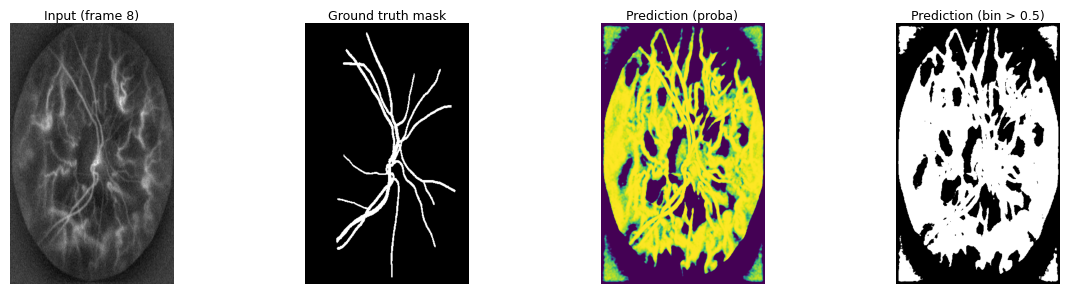

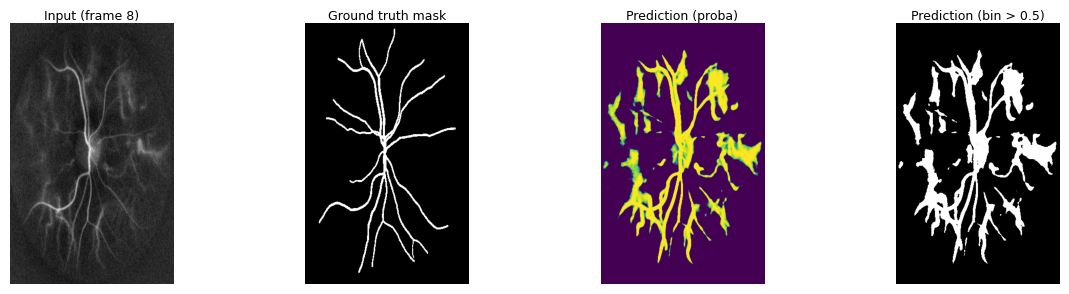

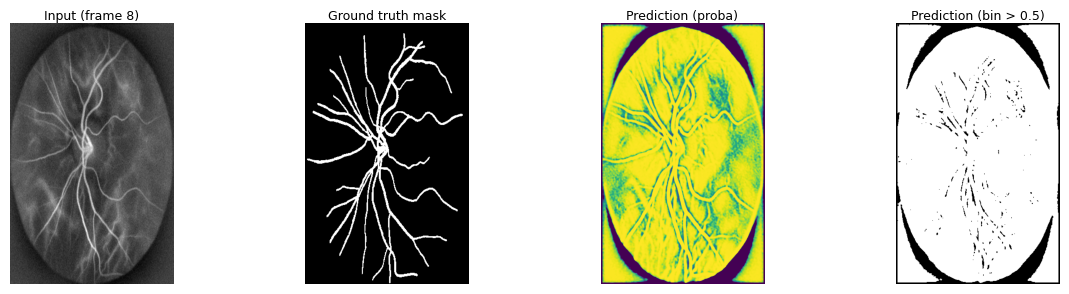

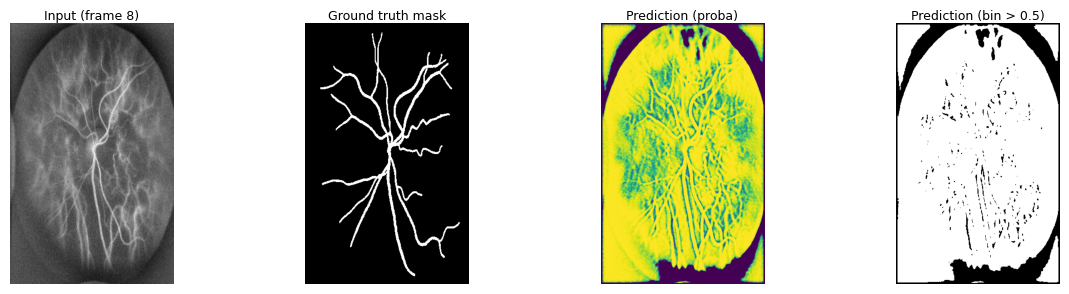

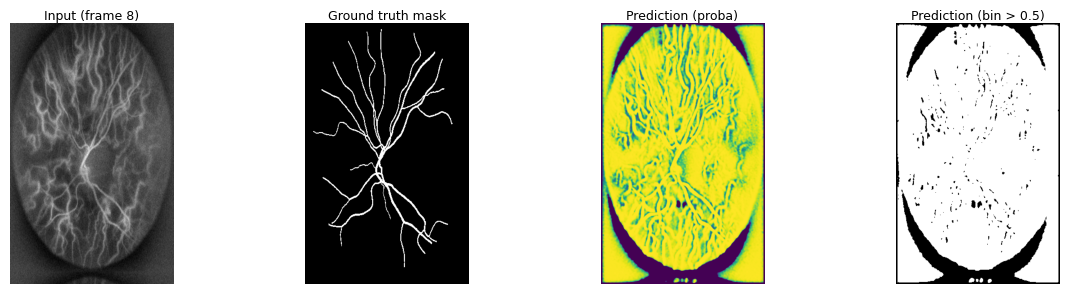

In [18]:
run_inference_and_plot(
    model_path="checkpoints/SGDNesterov_inner__SGDPlain_outer.pth",
    test_dataset=val_dl.dataset,
    num_samples=5,
    threshold=0.5,
)